## Classification( 분류 ) 모델

- 대표적인 지도학습
- 분류 모델 종류
    - 로지스틱 회귀 ( Logistic Regression ) # 회귀가 아닌 분류에 가깝다 
        - Sigmoid Function : 어떤 숫자가 들어와도 결과를 0과 1사이의 값으로 바꿔주는 함수를 기반으로 한 모델
    - Decision Tree
    - RandomForest ( 랜덤 포레스트 )
    - SVM ( Support Vector Machine ) : 서포트 벡터 머신
        - 데이터와 클래스 사이의 경계를 찾아서 분류
        - 데이터 포인트들을 고차원 공간으로 매핑하여 Decision Boundary( 결정 경계 )를 찾고
        - 이를 통해서 데이터를 분류하거나 예측
        - Margin ( 결정 경계 와 가장 가까운 거리에 있는 데이터 포인트 사이의 거리 )을 가진 Decision Boundary(결정 경계)를 찾음
        - Margin을 최대화하는 Decision Boundary를 찾고자 하는 모델이 바로 SVM 이다.     

In [43]:
# 데이터 분석 
import pandas as pd
import numpy as np

# 범주형 데이터 변환 
from sklearn.preprocessing import LabelEncoder # 이후부터 용어 변화 존재 
le = LabelEncoder()

# 머신러닝 지도학습, Decision Tree  모델 
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier , plot_tree # 대부분 모델에서 fier가 생성 
# plot_tree : Decision Tree 시각화 
from sklearn.metrics import accuracy_score , classification_report # 정확도

# 데이터 시각화 분석 라이브러리 
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 패치 표준

plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

In [10]:
iris = load_iris()

In [14]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [17]:
X, y = iris.data , iris.target

### 1. DataFrame 구조 생성 

In [18]:
df = pd.DataFrame(
    data = iris.data,
    columns = iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [19]:
df['target'] = iris.target

### 2. 데이터 구조 확인 

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [22]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### 3. X , y Split

In [75]:
X = df[[
    'sepal length (cm)',
    'sepal width (cm)',
    'petal length (cm)',
    'petal width (cm)'
]]

# 정답 데이터 y
y = df['target']

### 4. Train / Test Split

In [24]:
X_train , X_test , y_train , y_test = train_test_split(
    X , y,
    test_size = 0.2 , # 8 : 2  
    random_state = 42 , # 실행할 때마다 같은 결과가 나오도록 기준 유지 
    stratify = y ) # 품종 비율을 train/test 데이터에 거의 일정하게 유지 

In [30]:
y_train.shape

(120,)

In [29]:
y_test.shape

(30,)

### 5. 모델 생성 및 학습 

In [32]:
model = DecisionTreeClassifier(
    max_depth = 3 , # tree 의 최대 깊이 제한 
    random_state = 42)

In [33]:
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 6. 모델 Prediction

In [36]:
y_pred = model.predict(X_test)

# y_test.values
print(y_pred)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


### 7. 모델 평가

In [42]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9666666666666667


### 8. 분류 모델 성능 Report 

In [44]:
print(classification_report(
    y_test,
    y_pred,
    target_names = iris.target_names)
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



[분류 모델의 핵심 평가지표]

0. Accuracy : 전체 데이터 중 모델이 맞게 예측한 비율 > 전체 문제 중 몇개 맞혔는가?
1. precision : 모델이 해당 품종이라고 예측한 것 중 실제로 맞은 비율 > " setosa라고 예측한 것 중에서 진짜로 setosa 가 몇개 있는지 " 
2. recall : 실제 해당 품종 중 모델이 제대로 맞힌 비율 > " 진짜 setosa 중에서 모델이 setosa로 맞힌 개수 "
3. f1-score : precision과 recall을 종합한 조화 평균 점수
4. support : 실제 데이터 개수 

### 9. Decision Tree 구조 시각화 분석

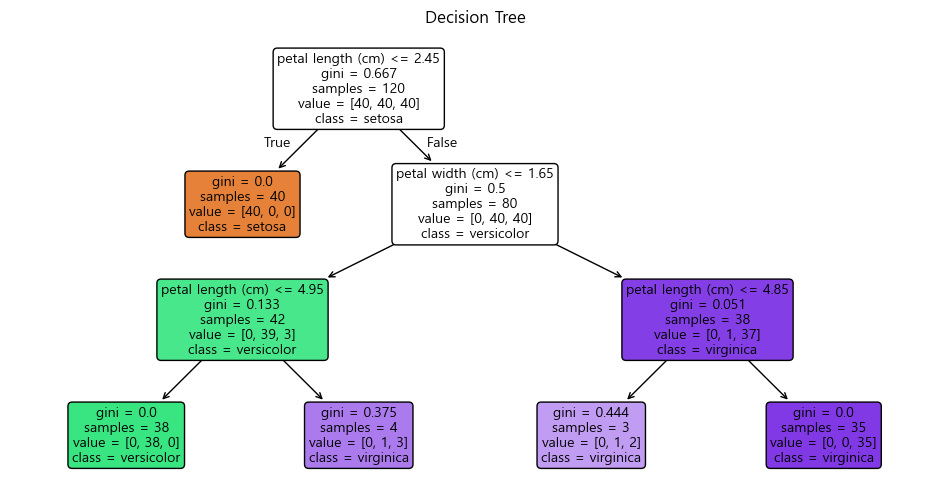

In [53]:
plt.figure(figsize = (12,6))

plot_tree(model ,
          feature_names = iris.feature_names , # 가장 잘 분류되는 feature 로 모델이 잡아줌 
          class_names = iris.target_names,
          filled = True ,  # tree에 색 구분 , 완벽하게 분류될수록 색이 진하다 
          rounded = True, # Decision Tree 모서리 처리 
          fontsize = 10) # font 크기 설정 

plt.title("Decision Tree")
plt.show()  

- petal length (cm) <= 2.45 : 분류 조건 : 꽃잎 길이가 2.45 이하인가?
- gini : 불순도 : 데이터가 얼마나 섞여 있는가?
    - gini : 데이터가 얼마나 섞여 있는지 나타냄
    - gini = 0 : 한종류만 있음 , 깨끗하게 분류 되어 있음 , gini가 클수록 여러 종류가 섞여 있음  
- samples = 데이터 개수 : 이 노드에 들어온 데이터 개수
- value : 클래스별 데이터 개수 :  setosa , versicolor , virginica 각각 몇개인가?
- class = 대표 예측 되는 클래스 : 이 노드에서 가장 많은 품종

In [54]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [55]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

### 10. Feature Importance 분석

In [74]:
importance = pd.DataFrame({
    'feature': iris.feature_names,
    'importance' : model.feature_importances_}) 

# sklearn에서 모델 학습 이후 생기는 값 뒤에는 _ 처리하는 경향이 존재함.

importance = importance.sort_values(
    by = 'importance',
    ascending = True # 내림차순 
)

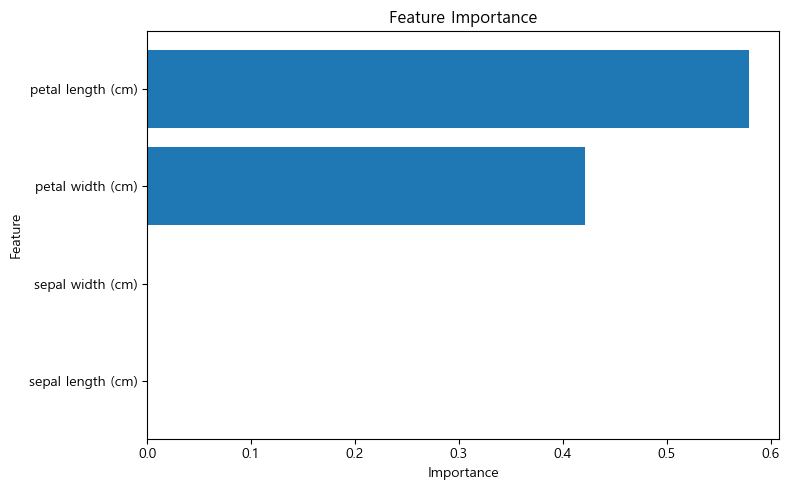

In [73]:
plt.figure(figsize=(8,5))

plt.barh(
    importance['feature'],
    importance['importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')

# plt.gca().invert_yaxis() # 현재의 그래프 Y축을 뒤집기
plt.tight_layout()
plt.show()